In [1]:
# verify version
import sys
assert sys.version.split('.')[0] == '3'
!which python

/home/nuru/git/nuru/env/bin/python


In [2]:
%load_ext autoreload
%autoreload 2

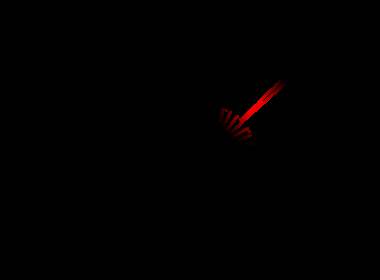

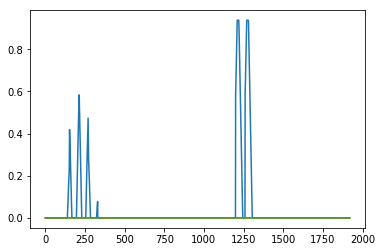

In [66]:
heart_palette = P.parse_colors_hex([
    (0, '000'),
    (0.8, 'f00'),
    (1, 'f00'),
])


x = (
    A.Dist2D(phi=np.pi/4, r=1.5)
    | S.Lin(1, -1)
    | S.Lin(0, L.Named('heart'))
    | C.Palette(heart_palette)
)

vs = x(heart=1)
plt.plot(vs)
DisplayS().draw(vs)

In [3]:
import collections, time

from matplotlib import pyplot as plt
import numpy as np
import numpy
import pandas
import scipy.io.wavfile
import scipy.signal

import pyaudio
# import aubio
# import bob.ap

In [5]:
import os.path, sys

lib_path = '../py'
assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
if not lib_path in sys.path:
    sys.path.insert(0, lib_path)

from smanmi import abase, audio, colors as C, effects as E, hotplug, logic as L, palette as P, signals as S, util
from nuru import animations as A, features, settings, state

Signal = L.Signal
Effect = E.Effect

# hp = hotplug.HotPlug()

# animations

## ColorPalette

In [200]:
def plot_palette(p, w=200, h=10, ax=None, title=None):
    cp = C.Palette(colors=p)
    if ax is None:
        plt.figure()
        ax = plt.gca()
    row = np.array([cp(value=v) for v in np.linspace(0, 1, w)])
    ax.imshow(np.array([
        row for y in range(h)
    ]))
    ax.set_xticks([])
    ax.set_yticks([])
    if title is not None:
        ax.set_title(title)

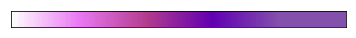

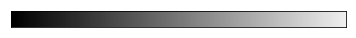

In [199]:
# easy to define new palettes

# https://coolors.co/ffffff-ea7af4-b43e8f-6200b3-8451ad
plot_palette(P.parse_colors_co_scss('''
$color1: rgba(255, 255, 255, 1);
$color2: rgba(234, 122, 244, 1);
$color3: rgba(180, 62, 143, 1);
$color4: rgba(98, 0, 179, 1);
$color5: rgba(132, 81, 173, 1);
'''))

plot_palette(P.parse_colors_hex([(0, '000'), (1, 'fff')]))

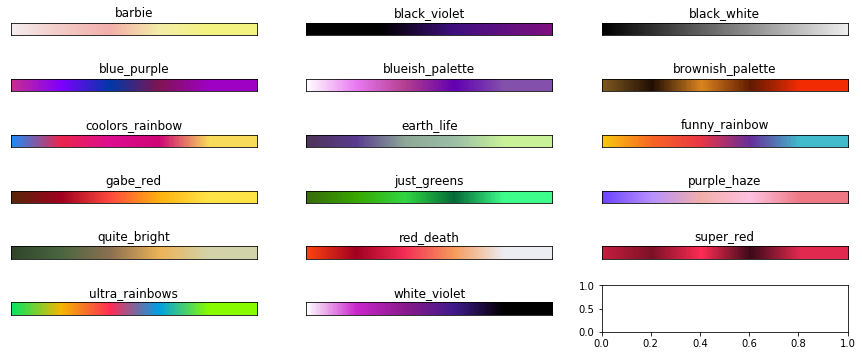

In [201]:
# currently predefined palettes

def ispalette(p):
    return isinstance(p, list) and len(p) > 1 and isinstance(p[0], P.ColorPoint)

palettes = {
    name: getattr(P, name)
    for name in dir(P)
    if ispalette(getattr(P, name))
}

cols = 3
rows = len(palettes) // cols + 1
_, axs = plt.subplots(rows, cols, figsize=(15, 6))
for i, name in enumerate(sorted(palettes)):
    ax = axs[i // cols][i % cols]
    plot_palette(palettes[name], ax=ax, title=name)

# r-phi

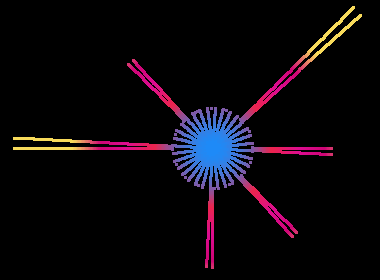

In [38]:
# slightly modified from ./mapping2.ipynb

from PIL import Image, ImageDraw

class Display:

    def __init__(self, width=800, height=600, d=2, scale=77):
        self.width = width
        self.height = height
        self.scale = scale
        self.d = d

    def circle(self, draw, phi, r, col, d):
        x = self.width * .56 + np.sin(phi) * self.scale * r
        y = self.height *  .53 - np.cos(phi) * self.scale * r
        draw.ellipse((x-d/2, y-d/2, x+d/2, y+d/2), fill=tuple(col))

    def draw(self, rgb):
        """Colors in `rgb` range from 0..1 for every pixel."""
        im = Image.new('RGB', (self.width, self.height), 'black')
        draw = ImageDraw.Draw(im)

        rgb = (255 * rgb).astype('uint8')
        for (phi, r), col in zip(A.phi_r_mapping, rgb):
            self.circle(draw, phi, r, col, self.d)
        return im

class DisplayS(Display):
    def __init__(self):
        super().__init__(width=380, height=280, d=2, scale=40)

anim = A.R() | S.Lin(0, 1/5) | S.Tocos() | C.Palette(P.coolors_rainbow)
DisplayS().draw(anim())

## gaussian

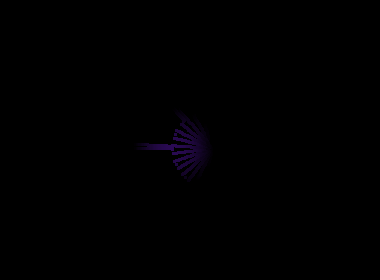

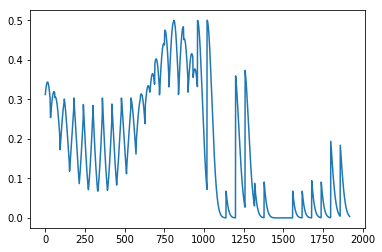

In [172]:
anim = A.GaussianDroplet(
    sigma=1,
    phi=3 * np.pi / 2,
    r=1,
) | S.Norm() | S.Lin(0, .5)
# anim = A.add([anim, anim])
plt.plot(anim())
anim |= C.Palette(P.black_violet)
DisplayS().draw(anim())

## heart

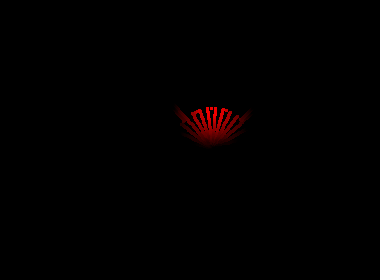

In [225]:
p = P.parse_colors_hex([
    (0, '000'),
    (0.8, 'f00'),
    (1, 'f00'),
])

anim = A.Dist2D(phi=0, r=1) | S.Lin(1, -1) | S.Lin(0, L.Named('heart')) | C.Palette(p)

DisplayS().draw(anim(heart=1))

## spiral

In [67]:
phi_r_mapping = A.phi_r_mapping

In [ ]:


spiral_palette = P.parse_colors_hex([
    (0, '000'),
    (0.3, 'f0f'),
    (0.4, 'f0f'),
    (0.6, 'f0f'),
    (0.7, 'f0f'),
    (1, '000'),
])


def spiral():
    return A.Spiral(0.1, 1) | S.Mod(1) | C.Palette(spiral_palette)



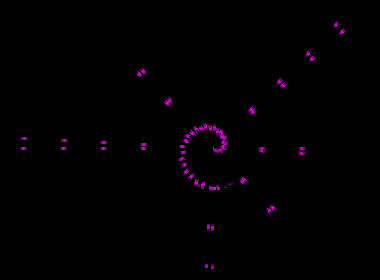

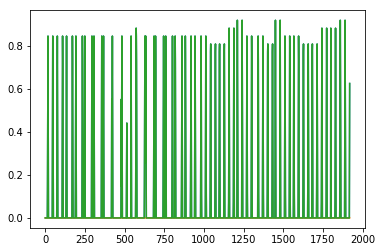

In [106]:
class Spiral(L.Signal):
    
    def init(self, dphi=1, dr=1.5):
        pass
    
    def call(self, t):
        return t + (
            phi_r_mapping[:, 0] * self.dphi
            + phi_r_mapping[:, 1] * self.dr
        )
    
anim = Spiral() | S.Mod(1) | C.Palette(P.coolors_rainbow)


spiral_palette = P.parse_colors_hex([
    (0, '000'),
    (0.4, '000'),
    (0.5, 'f0f'),
    (0.6, '000'),
    (1, '000'),
])


def spiral():
    return A.Spiral(.5/np.pi, 1) | S.Mod(1) | C.Palette(spiral_palette)


vs = spiral()(t=0)
plt.plot(vs);
DisplayS().draw(vs)


## compress waves

10.585000083063374
10.585000083063374


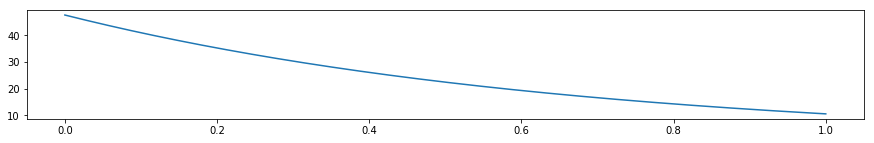

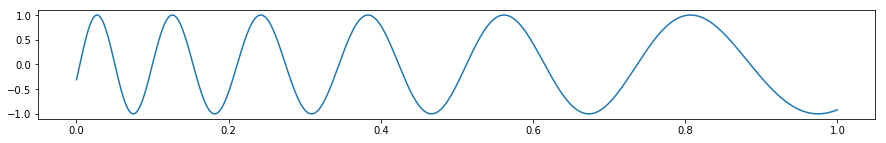

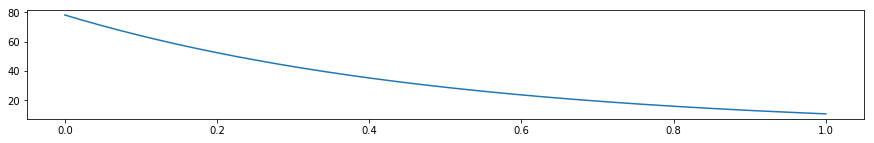

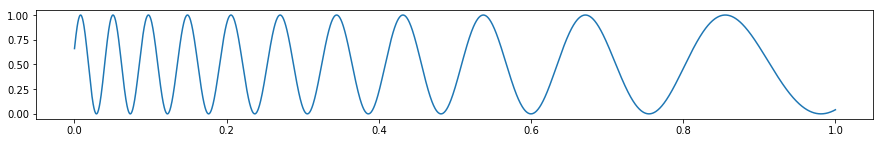

In [233]:
x = np.linspace(0, 1, 2000)
figsize = (15, 2)

u_ = u = 5 * np.exp((1.5 - x) * 1.5)
print(u[-1])
plt.figure(figsize=figsize)
plt.plot(x, u)
plt.figure(figsize=figsize)
plt.plot(x, np.sin(u))
u = 0.01 * np.exp((1.5 - x) * 2)
u *= u_[-1] / u[-1]
print(u[-1])
plt.figure(figsize=figsize)
plt.plot(x, u)
plt.figure(figsize=figsize)
plt.plot(x, 0.5 + 0.5 * np.sin(u))

None

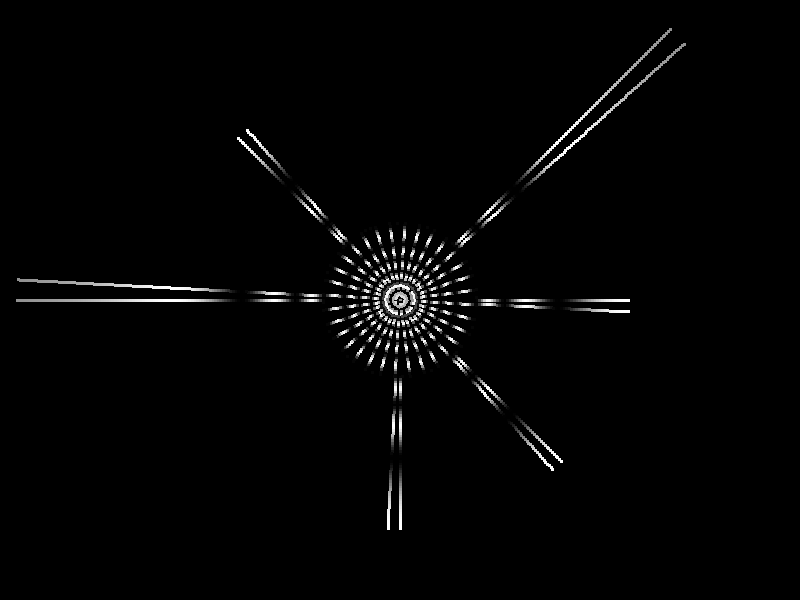

In [258]:
r = A.phi_r_mapping[:, 1]
x = r / r.max()

u = 5 * np.exp((1.5 - x) * 1.5)
u = 10 * np.exp((1.5 - x) * 1.5)
u = 5 * np.exp((1.5 - x) * 2)
u = 2 * np.exp((1.5 - x) * 3)
u = 0.2 * np.exp((1.5 - x) * 4)
u = 0.03 * np.exp((1.5 - x) * 5)
u = 0.007 * np.exp((1.5 - x) * 6)

v = 0.5 + 0.5 * np.sin(u)
Display().draw(np.vstack([v, v, v]).T)

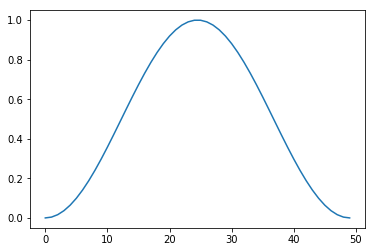

In [257]:
tocos = lambda x: 1 - (0.5 + 0.5 * np.cos(2 * x * np.pi))
plt.plot(tocos(np.linspace(0, 1)))

In [255]:
r = A.phi_r_mapping[:, 1]
x = r / r.max()

def cosipol(start=0, stop=1, steps=25):
    for phi in np.linspace(0, np.pi, steps):
        y = 1 - (0.5 + 0.5 * np.cos(phi))
        yield start + (stop - start) * y

ims = []
ue = (5 * np.exp((1.5 - x) * 1.5))[x.argmax()]
# for f in cosipol(.004, .006, 25):
#     u = f * np.exp((1.5 - x) * 6)
def forexp(exp):
    u = np.exp((1.5 - x) * exp)
    u *= ue / u[x.argmax()]
    return 0.5 + 0.5 * np.sin(u)
for exp in cosipol(1.5, 1.8, 25):
    vr = vg = vb = forexp(exp)
    vg = forexp(exp * 1.01) * 0
    vb = forexp(exp * 1.03)
    im = Display().draw(np.vstack([vr, vg, vb]).T)
    ims.append(im)
ims[0].save('generated.gif', append_images=ims[1:] + ims[::-1], save_all=True, duration=20, loop=0)
from IPython import display


In [217]:
!ls -lh *.gif

-rw-r--r--  1 andreassteiner  staff   2.1M Apr 26 22:47 test.gif


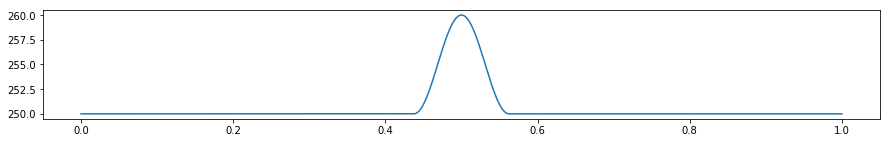

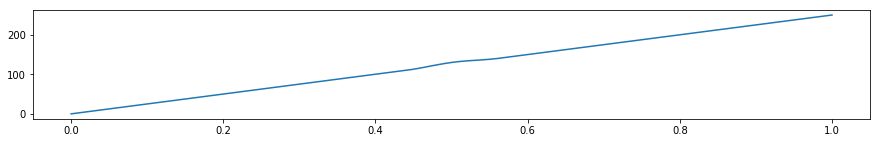

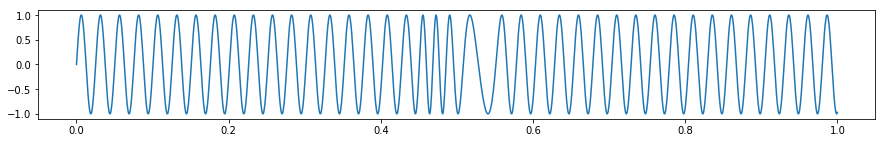

In [129]:
x = np.linspace(0, 1, 2000)
figsize = (15, 2)

f = 8
dx = 0.5
x_ = f * (x - dx)
pulse = np.piecewise(
    x_,
    [x_ < -0.5, x_ > -0.5, x_ > 0.5],
    [0, lambda x: 0.5 * (1 + np.cos(x * 2 * np.pi)), 0],
)
u = 250 + 10 * pulse
# u = 200 + 20 * pulse  # ugly b/c diff(u * x) is not >0 everywhere
plt.figure(figsize=figsize)
plt.plot(x, u)
plt.figure(figsize=figsize)
plt.plot(x, u * x)
plt.figure(figsize=figsize)
plt.plot(x, np.sin(x * u));

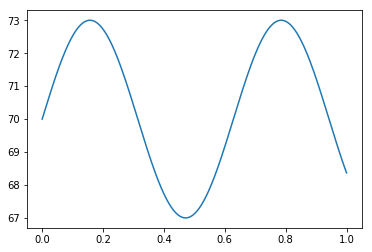

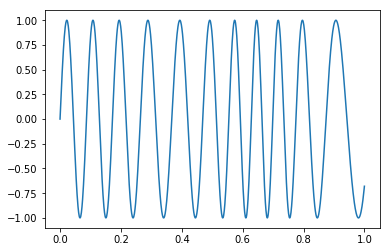

In [69]:
x = np.linspace(0, 1, 1000)

w = 70 + 3 * np.sin(10*x)
plt.plot(x, w)
plt.figure()
plt.plot(x, np.sin(x * w));

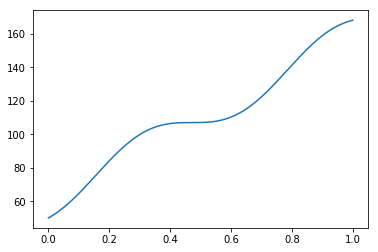

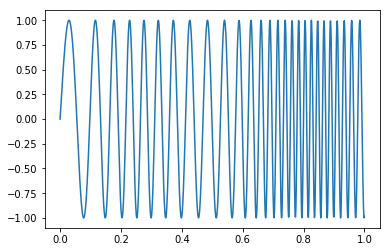

In [55]:
x = np.linspace(0, 1, 1000)

w = (1 + np.sin(10 * x)) / 10
w[0] = 50
w = w.cumsum()
plt.plot(x, w)
plt.figure()
plt.plot(x, np.sin(x * w));

# animated animations

using matplot lib animations...

you're probably better off using the new code above with the r-phi/GIF animations

In [209]:
import random
from matplotlib import animation, rc
from IPython.display import HTML

rc('animation', html='html5')

class MatplotlibAnimation:
    def __init__(self, xlim=[-1, 1], ylim=[-1, 1], frames=100, interval=20, figsize=(4, 4)):
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_xlim(xlim)
        self.ax.set_ylim(ylim)
        self.line, = self.ax.plot([], [])
        self.frames, self.interval = frames, interval

    def init(self):
        self.line.set_data([], [])
        return self.line,

    def step(self, i):
        return self.line,

    def animate(self, frames=None, interval=None):
        if frames is None: frames = self.frames
        if interval is None: interval = self.interval
        return animation.FuncAnimation(
            self.fig, self.step, init_func=self.init, frames=frames, interval=interval, blit=True)

    def play(self, animation=None, **animate_kw):
        if animation is None:
            animation = self.animate(**animate_kw)
        plt.close(animation._fig)
        return HTML(animation.to_html5_video())

## stereo drone

In [210]:
class ArmDecay(MatplotlibAnimation):
    def __init__(self, values, n=100):
        super().__init__(xlim=(0, 1), ylim=(0, 1.1), frames=len(values), figsize=(12, 4))
        self.values = values
        self.n = n
        self.xs = np.linspace(0, 1, n)
        self.frames = len(values)
        
    def f(self, v):
        return v * (1 - self.xs)**4

    def step(self, i):
        self.line.set_data(self.xs, self.f(self.values[i]))
        return self.line,

ramp = np.concatenate([
    np.linspace(0, 1, 20),
    np.ones(3*20),
    np.linspace(1, 0, 20),
])

In [211]:
ArmDecay(ramp).play()

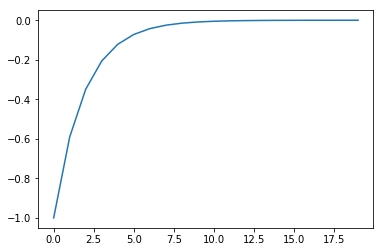

In [20]:
plt.plot(-np.exp(-np.linspace(0, 10, 20)))

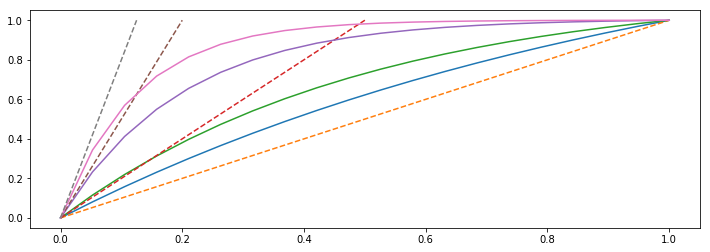

In [21]:
def decay(dx0, xs):
    """dx0 : initial steepness, xs : values 0..1"""
    ret = 1 - np.exp(-xs * dx0)
    return ret / ret[-1]

xs = np.linspace(0, 1, 20)
plt.figure(figsize=(12, 4))
for dx0 in (1, 2, 5, 8):
    plt.plot(xs, decay(dx0, xs))
    plt.plot([0, 1/dx0], [0, 1], '--')
# plt.plot(decay(2, xs))
# plt.plot(decay(4, xs))
# plt.plot(decay(8, xs))

In [22]:
class ArmImpulse(MatplotlibAnimation):
    def __init__(self, values, n=100):
        super().__init__(xlim=(0, 1), ylim=(0, 1.1), frames=len(values), figsize=(12, 4))
        self.values = values
        self.n = n
        self.xs = np.linspace(0, 1, n)
        self.frames = len(values)
        
    def f(self, v):
        return 1 * (np.abs(v - self.xs) < 0.02)

    def step(self, i):
        self.line.set_data(self.xs, self.f(self.values[i]))
        return self.line,

ramp = np.concatenate([
    np.linspace(0, 1, 40),
    np.ones(40),
])
ArmImpulse(ramp).play()

## chase

In [23]:

class RandomWalk(MatplotlibAnimation):
    def __init__(self):
        super().__init__()
        self.xs = []
        self.ys = []
        self.x = self.y = 0

    def step(self, i):
        self.x += random.random() * 0.2 - 0.1
        self.y += random.random() * 0.2 - 0.1
        self.xs.append(self.x)
        self.ys.append(self.y)
        self.line.set_data(self.xs, self.ys)
        return self.line,


class RandomWalkV(MatplotlibAnimation):
    def __init__(self):
        super().__init__()
        self.xs = []
        self.ys = []
        self.x = self.y = 0
        self.vx = self.vy = 0
    def step(self, i):
        self.vx += random.random() * 0.02 - 0.01
        self.vy += random.random() * 0.02 - 0.01
        self.x += self.vx
        self.y += self.vy
        if self.x < -1 or self.x > 1:
            self.x -= 2 * self.vx
            self.vx *= -1
        if self.y < -1 or self.y > 1:
            self.y -= 2 * self.vy
            self.vy *= -1
        self.xs.append(self.x)
        self.ys.append(self.y)
        self.line.set_data(self.xs, self.ys)
        return self.line,
    

class RandomWalkD(MatplotlibAnimation):
    def __init__(self):
        super().__init__()
        self.xs = []
        self.ys = []
        self.phi = 0
        self.x = self.y = 0
    def step(self, i):
        if self.x < -0.9 or self.x > 0.9:
            x, y = np.sin(self.phi), np.cos(self.phi)
            self.phi = np.arctan2(y, -x)
        if self.y < -0.9 or self.y > 0.9:
            x, y = np.sin(self.phi), np.cos(self.phi)
            self.phi = np.arctan2(-y, x)
        self.phi += (random.random() - 0.5) * np.pi / 5
        self.x += 0.1 * np.sin(self.phi)
        self.y += 0.1 * np.cos(self.phi)
        self.xs.append(self.x)
        self.ys.append(self.y)
        self.line.set_data(self.xs, self.ys)
        return self.line,

In [24]:
RandomWalkD().play(frames=100)

In [25]:
RandomWalkV().play(frames=300)

In [26]:
RandomWalk().play(frames=100)